<a href="https://colab.research.google.com/github/Syifamaulvi/PreprocessingData_Phyton/blob/main/Preprocessing_HBAT_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧹 Preprocessing Data HBAT
**Analisis Data dengan Python (Google Colab)**

Notebook ini mengajak kita melakukan *preprocessing data* secara utuh memakai dataset **HBAT** (survei pelanggan perusahaan pemasok kertas). Kita mulai dari data mentah yang berantakan sampai data bersih yang siap dipakai untuk analisis atau model, lengkap dengan visualisasinya.

### Roadmaps
| Langkah | Tahap | Pertanyaan yang dijawab |
|---|---|---|
| 1-2 | Import & Load data | Bagaimana data masuk ke Python? |
| 3 | Eksplorasi awal | Data ini isinya apa? |
| 4 | Pembersihan nama kolom & label | Apakah ada typo / format tidak konsisten? |
| 5 | Data duplikat | Ada responden yang tercatat dua kali? |
| 6 | **Missing value** | Berapa yang kosong, dan bagaimana mengisinya? |
| 7 | Validasi rentang nilai | Apakah ada nilai yang mustahil? |
| 8 | **Outlier** | Adakah nilai ekstrem? |
| 9 | **Visualisasi (EDA)** | Pola apa yang terlihat di data? |
| 10 | Feature engineering | Bisakah kita membuat variabel baru yang lebih bermakna? |
| 11 | Encoding | Bagaimana mengubah teks menjadi angka? |
| 12 | Split & Scaling | Bagaimana menyiapkan data untuk model? |
| 13 | Simpan hasil | Bagaimana menyimpan data bersih? |

### Kamus data HBAT (singkat)
- **Respondent ID**: nomor responden
- **Kolom kategori**: Customer Type (lama jadi pelanggan), Industry Type, Firm Size, Region, Distribution System, Future Alliance
- **13 kolom persepsi (skala 0-10)**: Product Quality, E-Commerce, Tech Support, Complaint Resolution, Advertising, Product Line, Salesforce, Pricing, Warranty, New Products, Ordering and Billing, Price Flexibility, Delivery Speed
- **Kolom hasil**: Customer Satisfaction, Recommendation, Future Purchase (skala 0-10) dan Purchase Share (proporsi 0-1)

> 💡 **Cara pakai:** jalankan sel satu per satu dengan menekan tombol ▶️ atau `Shift + Enter`. Jangan lompat urutan, karena sel di bawah memakai hasil sel di atasnya.

## Langkah 1: Import Library
Library adalah "kotak perkakas" di Python. Kita memakai:
- `pandas` : mengolah tabel data
- `numpy` : perhitungan angka
- `matplotlib` dan `seaborn` : membuat grafik
- `scikit-learn` : encoding, scaling, dan pembagian data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import warnings
warnings.filterwarnings("ignore")   # menyembunyikan peringatan kecil agar output rapi

# Pengaturan tampilan grafik
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

# Tampilkan semua kolom saat mencetak tabel
pd.set_option("display.max_columns", None)

print("Library siap dipakai!")

Library siap dipakai!


## Langkah 2: Memuat (Load) Data
Jalankan sel di bawah, lalu klik **Choose Files** dan pilih file `Latihan_HBAT_Data.xlsx` dari komputer kita.

> 📌 Alternatif: unggah file ke Google Drive lalu `from google.colab import drive; drive.mount('/content/drive')` dan ganti `nama_file` dengan lokasi file di Drive.

In [ ]:
from google.colab import files

uploaded = files.upload()                 # muncul tombol upload
nama_file = list(uploaded.keys())[0]      # ambil nama file yang diunggah

df = pd.read_excel(nama_file)             # baca file Excel menjadi tabel (DataFrame)
print("Berhasil membaca file:", nama_file)

Saving Latihan HBAT Data.xlsx to Latihan HBAT Data (1).xlsx
Berhasil membaca file: Latihan HBAT Data (1).xlsx


## Langkah 3: Eksplorasi Awal Data
Sebelum membersihkan, kita **kenali dulu** datanya. Ibarat dokter, periksa dulu sebelum mengobati.

In [ ]:
# 1) Berapa baris dan kolom?
print("Jumlah baris  :", df.shape[0])
print("Jumlah kolom  :", df.shape[1])

Jumlah baris  : 150
Jumlah kolom  : 24


In [ ]:
# 2) Lihat 10 baris pertama
df.head(10)

,Repondent ID,Customer Type,Industry Type,Firm Size,Region,Distribution System,Product Quality,E-Commerce,Tech Support,Complaint Resolution,Advertising,Product Line,Salesforce,Pricing,Warranty,New Products,Ordering and Billing,Price Flexibility,Delivery Speed,Customer Satisfaction,Recommendation,Future Purchase,Purchase Share,Future Alliance
0,1,Fewer than 1 year,magazine industry,500 or more employees,Outside North America,Sold through broker,8.1,2.5,7.2,4.5,2.3,5.1,3.8,6.6,6.8,6.1,3.0,3.5,3.0,6.4,5.8,6.2,0.51,Would not consider
1,2,Fewer than 1 year,magazine industry,Fewer than 500 employes,Outside North America,Sold directly,7.6,3.6,7.6,4.6,4.7,4.6,5.0,7.4,8.1,6.6,4.5,5.8,3.9,6.4,6.9,7.5,0.49,Would not consider
2,3,NaN,NaN,500 or more employees,Outside North America,NaN,NaN,NaN,6.3,NaN,4.4,3.9,6.4,8.2,5.8,5.9,3.0,NaN,NaN,NaN,NaN,NaN,0.53,Would not consider
3,4,1-5 year,magazine industry,500 or more employees,Outside North America,Sold directly,7.4,5.1,4.8,7.7,4.5,7.2,6.9,9.6,6.4,7.4,5.7,6.5,5.5,9.0,7.9,8.8,0.74,Consider Partnership
4,5,More than 5 year,magazine industry,500 or more employees,Outside North America,Sold through broker,9.1,4.5,3.6,6.4,5.3,5.3,7.1,8.4,5.8,6.7,4.5,6.1,4.4,7.6,8.5,8.8,0.67,Consider Partnership
5,6,Fewer than 1 year,magazine industry,Fewer than 500 employes,Outside North America,Sold through broker,5.0,3.6,1.3,3.0,3.5,4.2,4.9,8.2,4.3,7.6,2.4,4.8,3.1,5.2,5.5,6.0,0.48,Would not consider
6,7,More than 5 year,magazine industry,Fewer than 500 employes,USA/North America,Sold through broker,8.7,3.2,4.0,6.8,3.2,7.8,3.8,4.9,6.1,5.0,4.3,3.9,4.5,6.6,6.4,7.1,0.71,Would not consider
7,8,Fewer than 1 year,newsprint industry,500 or more employees,Outside North America,Sold through broker,7.5,3.5,4.1,4.5,3.5,4.1,4.5,7.6,4.9,2.8,3.4,5.4,3.4,5.2,6.0,7.2,0.51,Would not consider
8,9,Fewer than 1 year,NaN,500 or more employees,Outside North America,Sold through broker,6.7,4.0,5.2,3.9,3.0,NaN,6.8,8.4,6.2,6.0,NaN,4.3,3.5,6.3,NaN,6.7,0.54,NaN
9,10,Fewer than 1 year,newsprint industry,Fewer than 500 employes,USA/North America,Sold directly,6.9,3.4,8.5,4.3,4.5,6.4,4.7,5.2,7.7,3.3,3.7,2.7,3.3,6.1,6.8,7.1,0.44,Would not consider


In [ ]:
# 3) Informasi tipe data tiap kolom dan jumlah data yang terisi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Repondent ID           150 non-null    int64  
 1   Customer Type          131 non-null    object 
 2   Industry Type          130 non-null    object 
 3   Firm Size              133 non-null    object 
 4   Region                 139 non-null    object 
 5   Distribution System    139 non-null    object 
 6   Product Quality        128 non-null    float64
 7   E-Commerce             130 non-null    float64
 8   Tech Support           134 non-null    float64
 9   Complaint Resolution   131 non-null    float64
 10  Advertising            131 non-null    float64
 11  Product Line           135 non-null    float64
 12  Salesforce             140 non-null    float64
 13  Pricing                135 non-null    float64
 14  Warranty               136 non-null    float64
 15  New Pr

In [ ]:
# 4) Statistik ringkas untuk kolom angka
# df.describe().T
df.describe()

,Repondent ID,Product Quality,E-Commerce,Tech Support,Complaint Resolution,Advertising,Product Line,Salesforce,Pricing,Warranty,New Products,Ordering and Billing,Price Flexibility,Delivery Speed,Customer Satisfaction,Recommendation,Future Purchase,Purchase Share
count,150.000000,128.000000,130.000000,134.000000,131.000000,131.000000,135.000000,140.000000,135.000000,136.000000,131.000000,134.000000,138.000000,131.000000,136.000000,131.000000,136.00000,150.000000
mean,75.500000,7.786719,3.673846,5.376866,5.505344,4.003053,5.840000,5.132857,6.980000,6.018382,5.108397,4.326119,4.678986,3.898473,6.903676,6.989313,7.68750,0.533200
std,43.445368,1.402606,0.679096,1.495754,1.179460,1.086557,1.373643,1.105086,1.571376,0.803068,1.442596,0.928086,1.211228,0.730014,1.190232,1.071609,0.95835,0.190624
min,1.000000,5.000000,2.200000,1.300000,2.600000,1.900000,2.300000,2.900000,3.700000,4.100000,1.700000,2.000000,2.600000,1.600000,4.700000,4.600000,5.50000,0.000000
25%,38.250000,6.500000,3.300000,4.600000,4.600000,3.200000,4.700000,4.500000,5.850000,5.400000,4.100000,3.825000,3.725000,3.400000,6.000000,6.300000,7.10000,0.500000
50%,75.500000,8.000000,3.600000,5.400000,5.500000,4.000000,5.800000,5.000000,7.100000,6.100000,5.000000,4.400000,4.500000,4.000000,7.000000,7.000000,7.65000,0.580000
75%,112.750000,9.100000,4.000000,6.600000,6.400000,4.700000,6.900000,5.800000,8.400000,6.500000,6.150000,4.875000,5.800000,4.500000,7.600000,7.700000,8.40000,0.650000
max,150.000000,10.000000,5.700000,8.500000,7.800000,6.500000,8.400000,8.200000,9.900000,8.100000,9.500000,6.700000,7.300000,5.500000,9.900000,9.900000,9.90000,0.770000


In [ ]:
# 5) Cek Isi kolom kategori: ada kategori apa saja dan berapa banyak?
kolom_teks = ["Customer Type", "Industry Type", "Firm Size", "Region",
              "Distribution System", "Future Alliance"]

for kol in kolom_teks:
    print("=== " + kol + " ===")
    print(df[kol].value_counts(dropna=False))   # dropna=False -> data kosong ikut dihitung
    print()

=== Customer Type ===
Customer Type
1-5 year             47
Fewer than 1 year    43
More than 5 year     41
NaN                  19
Name: count, dtype: int64

=== Industry Type ===
Industry Type
magazine industry     69
newsprint industry    61
NaN                   20
Name: count, dtype: int64

=== Firm Size ===
Firm Size
500 or more employees      70
Fewer than 500 employes    63
NaN                        17
Name: count, dtype: int64

=== Region ===
Region
Outside North America    87
USA/North America        52
NaN                      11
Name: count, dtype: int64

=== Distribution System ===
Distribution System
Sold through broker    81
Sold directly          58
NaN                    11
Name: count, dtype: int64

=== Future Alliance ===
Future Alliance
Would not consider      71
Consider Partnership    62
NaN                     17
Name: count, dtype: int64



**📝 Catatan pengamatan (diskusikan di kelas):**
1. Kolom `Repondent ID` tampaknya salah ketik (seharusnya *Respondent*).
2. Pada `Firm Size` ada label `Fewer than 500 employes`, sepertinya typo *employees*.
3. Jumlah data terisi pada `info()` berbeda-beda per kolom, artinya ada **missing value**.

## Langkah 4: Merapikan Nama Kolom dan Label
Data yang bersih itu **konsisten**. Typo kecil bisa membuat satu kategori terpecah menjadi dua.

In [ ]:
# Membuang spasi berlebih di awal/akhir nama kolom
df.columns = df.columns.str.strip()

# Memperbaiki typo nama kolom
df = df.rename(columns={"Repondent ID": "Respondent ID"})

# Membuang spasi berlebih pada isi kolom teks, lalu memperbaiki typo label
for kol in kolom_teks:
    df[kol] = df[kol].str.strip()

df["Firm Size"] = df["Firm Size"].replace({"Fewer than 500 employes": "Fewer than 500 employees"})

# Kelompokkan nama kolom supaya mudah dipakai berulang
kolom_kategori = kolom_teks
kolom_persepsi = ["Product Quality", "E-Commerce", "Tech Support", "Complaint Resolution",
                  "Advertising", "Product Line", "Salesforce", "Pricing", "Warranty",
                  "New Products", "Ordering and Billing", "Price Flexibility", "Delivery Speed"]
kolom_hasil    = ["Customer Satisfaction", "Recommendation", "Future Purchase", "Purchase Share"]
kolom_numerik  = kolom_persepsi + kolom_hasil

print(df["Firm Size"].value_counts(dropna=False))
print(kolom_numerik)

Firm Size
500 or more employees       70
Fewer than 500 employees    63
NaN                         17
Name: count, dtype: int64
['Product Quality', 'E-Commerce', 'Tech Support', 'Complaint Resolution', 'Advertising', 'Product Line', 'Salesforce', 'Pricing', 'Warranty', 'New Products', 'Ordering and Billing', 'Price Flexibility', 'Delivery Speed', 'Customer Satisfaction', 'Recommendation', 'Future Purchase', 'Purchase Share']


## Langkah 5: Mengecek Data Duplikat
Responden yang tercatat dua kali akan "menggandakan suara" dan membuat hasil analisis bias.

In [ ]:
print("Baris duplikat (seluruh kolom sama):", df.duplicated().sum())
print("ID responden yang duplikat         :", df["Respondent ID"].duplicated().sum())

# Jika ada duplikat, buang dengan baris berikut
df = df.drop_duplicates()
print("Jumlah baris sekarang:", len(df))

Baris duplikat (seluruh kolom sama): 0
ID responden yang duplikat         : 0
Jumlah baris sekarang: 150


Hasilnya **0**, artinya aman. Tetapi mengecek duplikat tetap wajib dilakukan pada setiap proyek data.

## Langkah 6: Menangani Missing Value (Data Kosong)
Ini tahap yang paling sering memakan waktu. Alurnya:
1. **Hitung** berapa data yang kosong
2. **Lihat polanya** (visualisasi)
3. **Putuskan strategi**: buang baris yang terlalu kosong, lalu isi sisanya

### 6.1 Hitung jumlah dan persentase missing value

In [ ]:
jumlah_missing = df.isnull().sum()
persen_missing = (jumlah_missing / len(df) * 100).round(2)

tabel_missing = pd.DataFrame({"Jumlah Missing": jumlah_missing,
                              "Persen (%)": persen_missing})
tabel_missing.index.name = "Kolom"
tabel_missing

,Jumlah Missing,Persen (%)
Kolom,,
Respondent ID,0,0.00
Customer Type,19,12.67
Industry Type,20,13.33
Firm Size,17,11.33
Region,11,7.33
Distribution System,11,7.33
Product Quality,22,14.67
E-Commerce,20,13.33
Tech Support,16,10.67


### 6.2 Visualisasikan missing value

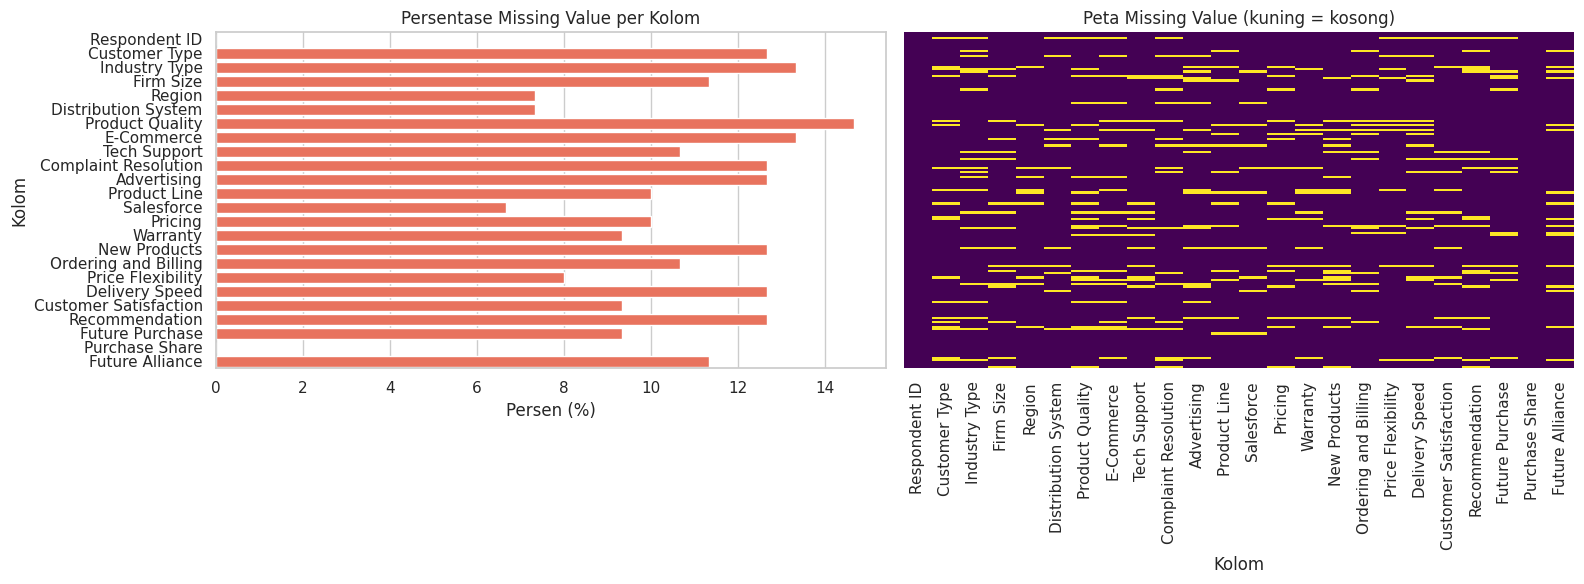

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# persentase missing per kolom
tm = tabel_missing.reset_index()
sns.barplot(data=tm, x="Persen (%)", y="Kolom", color="tomato", ax=axes[0])
axes[0].set_title("Persentase Missing Value per Kolom")

# Heatmaps missing value (garis terang = data kosong)
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=axes[1])
axes[1].set_title("Peta Missing Value (kuning = kosong)")

plt.tight_layout()
plt.show()

**Cara membaca heatmap:** setiap garis kuning adalah sel kosong. Perhatikan beberapa baris punya **banyak** garis kuning (responden yang hampir tidak mengisi kuesioner).

### 6.3 Missing value per baris (per responden)

Baris yang lengkap (tanpa missing): 100
Baris dengan minimal 1 missing    : 50



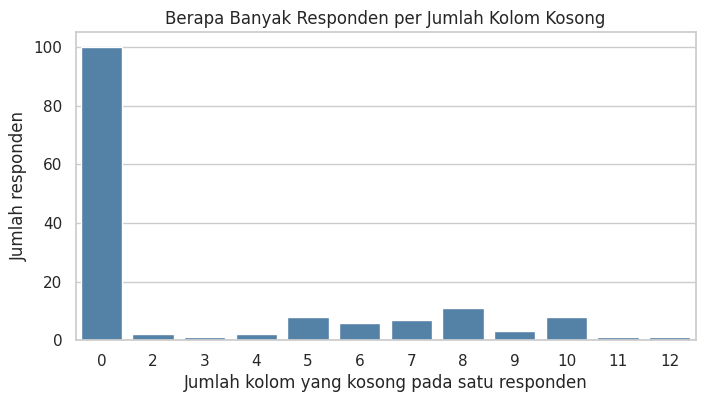

In [ ]:
kolom_analisis = [c for c in df.columns if c != "Respondent ID"]
df["Jumlah Kosong"] = df[kolom_analisis].isnull().sum(axis=1)

print("Baris yang lengkap (tanpa missing):", (df["Jumlah Kosong"] == 0).sum())
print("Baris dengan minimal 1 missing    :", (df["Jumlah Kosong"] > 0).sum())
print()

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Jumlah Kosong", color="steelblue")
plt.title("Berapa Banyak Responden per Jumlah Kolom Kosong")
plt.xlabel("Jumlah kolom yang kosong pada satu responden")
plt.ylabel("Jumlah responden")
plt.show()

### 6.4 Strategi 1: Buang baris yang terlalu kosong
Kalau satu responden **lebih dari 40% jawabannya kosong**, mengisinya dengan angka tebakan justru berbahaya karena kita hampir "mengarang" responden itu. Lebih baik dibuang.

> Kalau kita pakai `dropna()` pada semua baris yang punya missing, kita akan kehilangan banyak data. Maka dari itu kita pakai **ambang batas**. Silakan ubah angka `0.40` untuk bereksperimen.

In [ ]:
batas_missing = 0.40    # ubah-ubah angka ini untuk eksperimen

persen_kosong_baris = df[kolom_analisis].isnull().mean(axis=1)
baris_dibuang = persen_kosong_baris > batas_missing

print("Jika memakai dropna() biasa, baris yang hilang:", len(df) - len(df.dropna()))
print("Dengan ambang batas", int(batas_missing*100), "%, baris yang dibuang:", baris_dibuang.sum())

df = df[~baris_dibuang].reset_index(drop=True)
df = df.drop(columns="Jumlah Kosong")
print("Jumlah baris sekarang:", len(df))

Jika memakai dropna() biasa, baris yang hilang: 50
Dengan ambang batas 40 %, baris yang dibuang: 10
Jumlah baris sekarang: 140


### 6.5 Strategi 2: Mengisi (imputasi) sisa missing value
Aturan praktis:
| Jenis kolom | Isi dengan | Alasan |
|---|---|---|
| Angka | **Median** | Tidak terpengaruh nilai ekstrem |
| Kategori (teks) | **Modus** (nilai paling sering muncul) | Paling masuk akal untuk data teks |

In [ ]:
# Simpan salinan data sebelum diisi, untuk dibandingkan nanti
df_sebelum_imputasi = df.copy()

# Isi kolom angka dengan median
for kol in kolom_numerik:
    df[kol] = df[kol].fillna(df[kol].median())

# Isi kolom kategori dengan modus
for kol in kolom_kategori:
    df[kol] = df[kol].fillna(df[kol].mode()[0])

print("Total missing value sekarang:", df.isnull().sum().sum())

Total missing value sekarang: 0


### 6.6 Periksa: apakah pengisian mengubah bentuk data terlalu jauh?

In [ ]:
perbandingan = pd.DataFrame({
    "Mean sebelum": df_sebelum_imputasi[kolom_numerik].mean(),
    "Mean sesudah": df[kolom_numerik].mean(),
    "Std sebelum":  df_sebelum_imputasi[kolom_numerik].std(),
    "Std sesudah":  df[kolom_numerik].std(),
}).round(3)
perbandingan

,Mean sebelum,Mean sesudah,Std sebelum,Std sesudah
Kolom,,,,
Product Quality,7.772,7.800,1.406,1.319
E-Commerce,3.675,3.668,0.677,0.643
Tech Support,5.340,5.336,1.508,1.447
Complaint Resolution,5.493,5.494,1.193,1.132
Advertising,4.015,4.014,1.086,1.025
Product Line,5.824,5.826,1.343,1.284
Salesforce,5.110,5.098,1.080,1.050
Pricing,7.015,7.025,1.569,1.512
Warranty,6.011,6.017,0.814,0.787


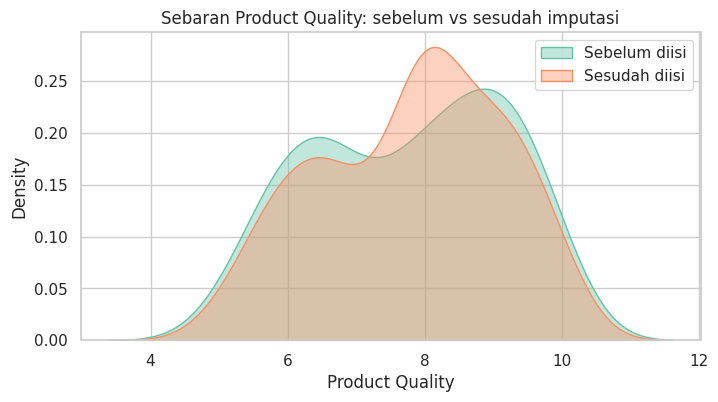

In [ ]:
# Bandingkan sebaran sebelum dan sesudah imputasi pada satu kolom
kol = "Product Quality"

plt.figure(figsize=(8, 4))
sns.kdeplot(df_sebelum_imputasi[kol].dropna(), label="Sebelum diisi", fill=True, alpha=0.4)
sns.kdeplot(df[kol], label="Sesudah diisi", fill=True, alpha=0.4)
plt.title("Sebaran " + kol + ": sebelum vs sesudah imputasi")
plt.legend()
plt.show()

**Kesimpulan:** rata-rata hampir tidak berubah, tetapi simpangan baku (*std*) sedikit mengecil. Itu **efek samping imputasi median**: banyak nilai ditumpuk di titik tengah. Hal ini wajar dan perlu kita sadari. (Teknik lanjutan seperti `KNNImputer` bisa dicoba sebagai tugas mandiri.)

## Langkah 7: Validasi Rentang Nilai
Skala kuesioner HBAT adalah **0-10**, dan Purchase Share adalah **0-1**. Nilai di luar itu pasti kesalahan input (*data entry error*).

In [ ]:
kolom_skor = kolom_persepsi + ["Customer Satisfaction", "Recommendation", "Future Purchase"]

# Tabel nilai minimum dan maksimum
df[kolom_numerik].agg(["min", "max"]).T

,min,max
Kolom,,
Product Quality,5.0,10.00
E-Commerce,2.2,5.70
Tech Support,1.3,8.50
Complaint Resolution,2.6,7.80
Advertising,1.9,6.50
Product Line,2.3,8.40
Salesforce,2.9,8.20
Pricing,3.7,9.90
Warranty,4.1,8.10


In [ ]:
di_luar_skala = ((df[kolom_skor] < 0) | (df[kolom_skor] > 10)).sum().sum()
di_luar_share = ((df["Purchase Share"] < 0) | (df["Purchase Share"] > 1)).sum()

print("Nilai skor di luar 0-10          :", di_luar_skala)
print("Purchase Share di luar rentang 0-1:", di_luar_share)

Nilai skor di luar 0-10          : 0
Purchase Share di luar rentang 0-1: 0


Hasilnya 0, jadi semua nilai valid. Seandainya ada yang salah, kita perbaiki atau ubah menjadi `NaN` lalu isi dengan cara di Langkah 6.

## Langkah 8: Mendeteksi dan Menangani Outlier
**Outlier** adalah nilai yang jauh berbeda dari mayoritas data. Kita deteksi dengan **aturan IQR**:

- Q1 = kuartil 25%, Q3 = kuartil 75%, IQR = Q3 - Q1
- Batas bawah = Q1 - 1.5 x IQR
- Batas atas = Q3 + 1.5 x IQR
- Nilai di luar batas = outlier

> ⚠️ Outlier **tidak selalu salah**. Bisa jadi itu responden yang memang berpendapat ekstrem. Keputusan membuang atau mempertahankan harus dipikirkan.

In [ ]:
def batas_iqr(data, kolom):
    q1 = data[kolom].quantile(0.25)
    q3 = data[kolom].quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

hasil = []
for kol in kolom_numerik:
    bawah, atas = batas_iqr(df, kol)
    jumlah = ((df[kol] < bawah) | (df[kol] > atas)).sum()
    hasil.append({"Kolom": kol, "Batas Bawah": round(bawah, 2),
                  "Batas Atas": round(atas, 2), "Jumlah Outlier": jumlah})

tabel_outlier = pd.DataFrame(hasil).sort_values("Jumlah Outlier", ascending=False)
tabel_outlier

,Kolom,Batas Bawah,Batas Atas,Jumlah Outlier
16,Purchase Share,0.27,0.88,13
1,E-Commerce,2.40,4.80,11
10,Ordering and Billing,2.55,6.15,10
15,Future Purchase,5.64,9.74,8
6,Salesforce,2.55,7.75,4
12,Delivery Speed,2.09,5.79,3
9,New Products,1.35,8.95,2
14,Recommendation,4.54,9.44,2
13,Customer Satisfaction,3.79,9.89,1
2,Tech Support,1.86,9.16,1


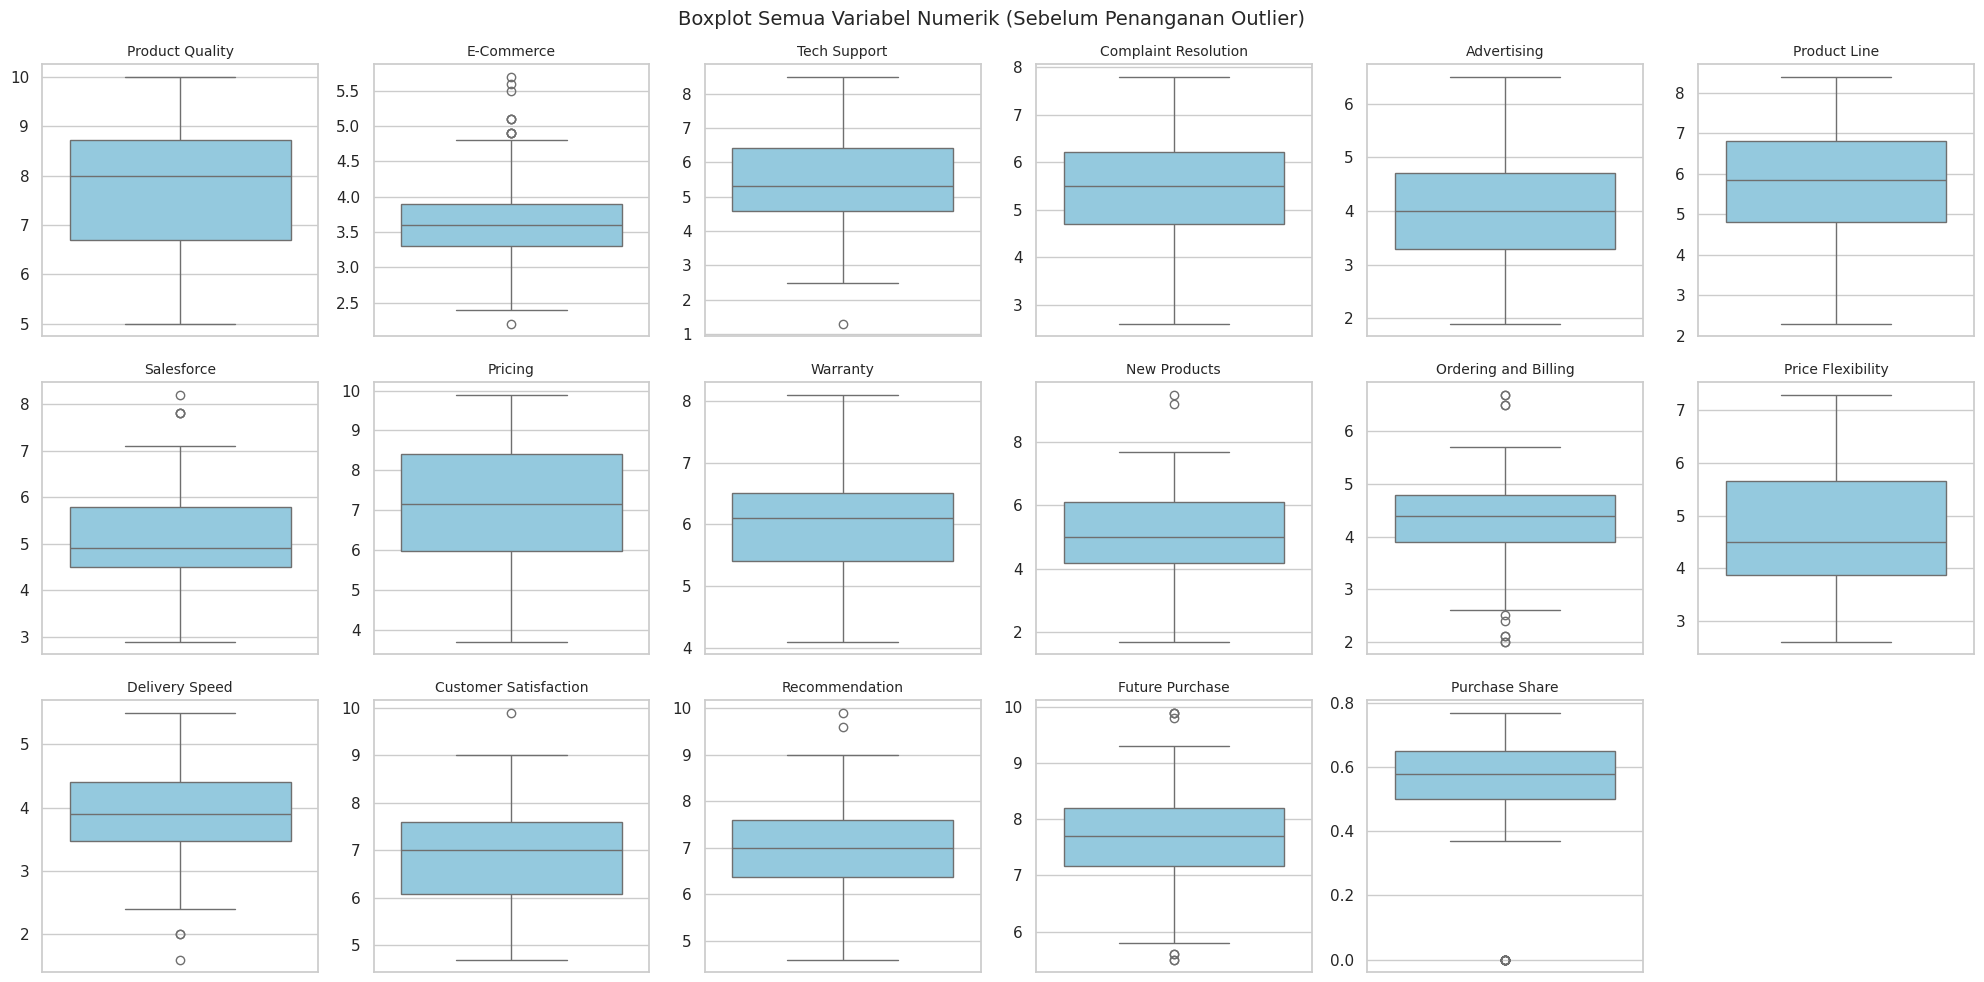

In [ ]:
# Boxplot: titik di luar "kumis" adalah outlier
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()

for i, kol in enumerate(kolom_numerik):
    sns.boxplot(y=df[kol], ax=axes[i], color="skyblue")
    axes[i].set_title(kol, fontsize=10)
    axes[i].set_ylabel("")

for j in range(len(kolom_numerik), len(axes)):   # matikan kotak kosong
    axes[j].axis("off")

plt.suptitle("Boxplot Semua Variabel Numerik (Sebelum Penanganan Outlier)", fontsize=14)
plt.tight_layout()
plt.show()

### Menangani outlier dengan *capping* (winsorizing)
Nilai yang melewati batas **tidak dibuang**, tetapi "ditarik" ke batas terdekat. Cara ini menjaga jumlah data tetap utuh.

In [ ]:
df_sebelum_outlier = df.copy()

for kol in kolom_numerik:
    bawah, atas = batas_iqr(df, kol)
    df[kol] = df[kol].clip(lower=bawah, upper=atas)

# Cek ulang
sisa = 0
for kol in kolom_numerik:
    bawah, atas = batas_iqr(df, kol)
    sisa += ((df[kol] < bawah) | (df[kol] > atas)).sum()
print("Jumlah outlier setelah capping:", sisa)

Jumlah outlier setelah capping: 0


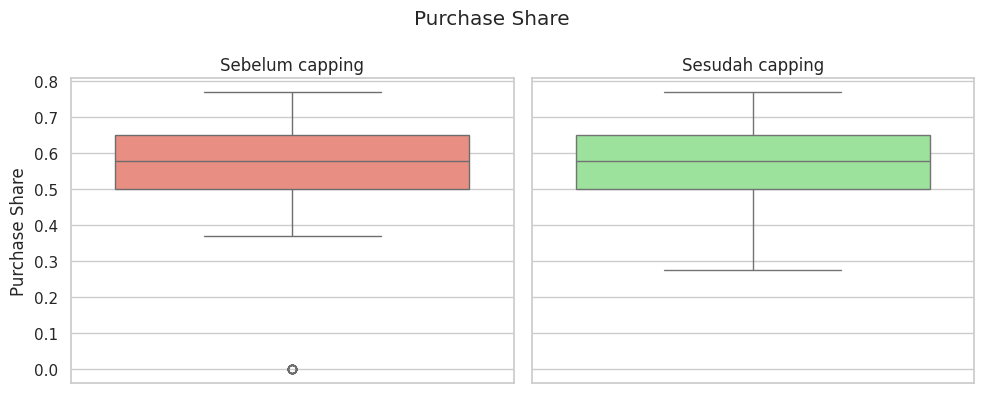

In [ ]:
# Bandingkan sebelum vs sesudah pada kolom yang outliernya terbanyak
kol_terbanyak = tabel_outlier.iloc[0]["Kolom"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
sns.boxplot(y=df_sebelum_outlier[kol_terbanyak], ax=axes[0], color="salmon")
axes[0].set_title("Sebelum capping")
sns.boxplot(y=df[kol_terbanyak], ax=axes[1], color="lightgreen")
axes[1].set_title("Sesudah capping")
plt.suptitle(kol_terbanyak)
plt.tight_layout()
plt.show()

## Langkah 9: Visualisasi Data (Exploratory Data Analysis)
Data kita sekarang sudah bersih. Saatnya **melihat pola** di dalamnya. Setiap grafik menjawab pertanyaan berbeda.

### 9.1 Sebaran tiap variabel numerik (histogram)
*Pertanyaan: apakah datanya condong ke kiri/kanan atau simetris?*

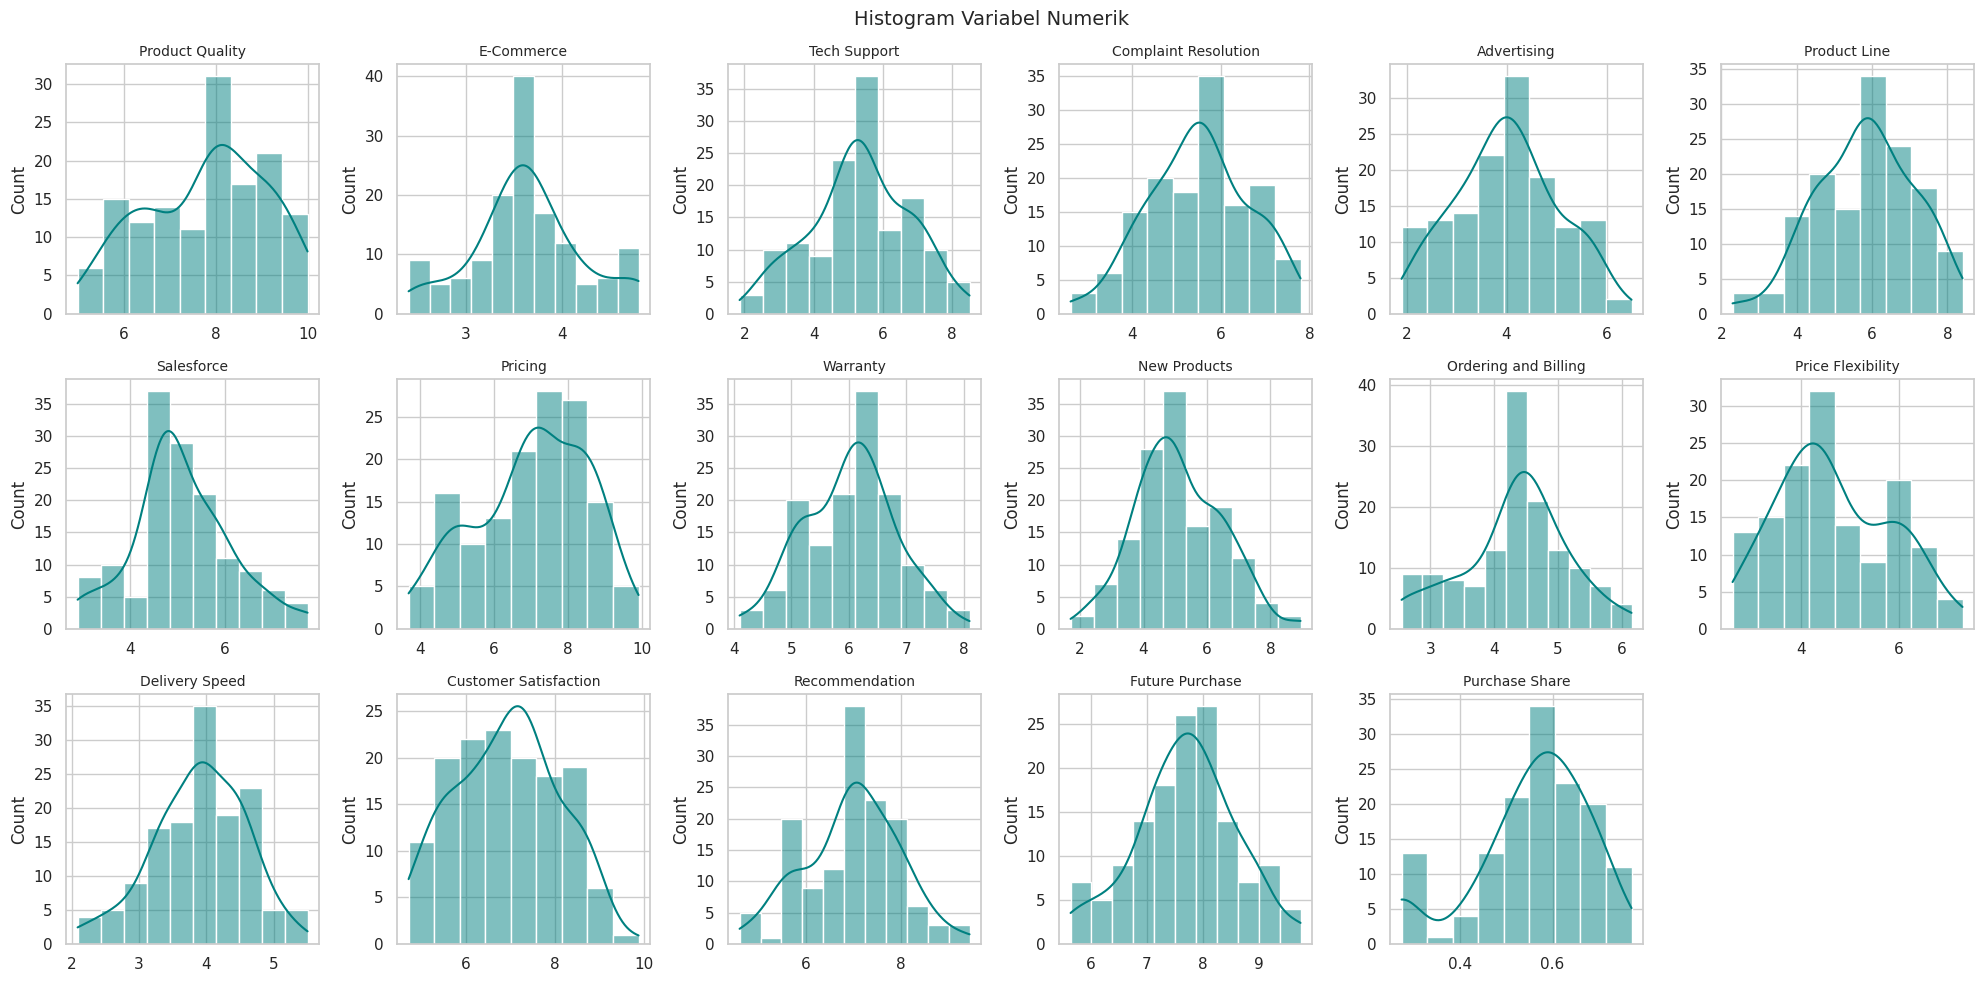

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()

for i, kol in enumerate(kolom_numerik):
    sns.histplot(df[kol], kde=True, ax=axes[i], color="teal")
    axes[i].set_title(kol, fontsize=10)
    axes[i].set_xlabel("")

for j in range(len(kolom_numerik), len(axes)):
    axes[j].axis("off")

plt.suptitle("Histogram Variabel Numerik", fontsize=14)
plt.tight_layout()
plt.show()

### 9.2 Komposisi responden (countplot)
*Pertanyaan: seperti apa profil responden kita?*

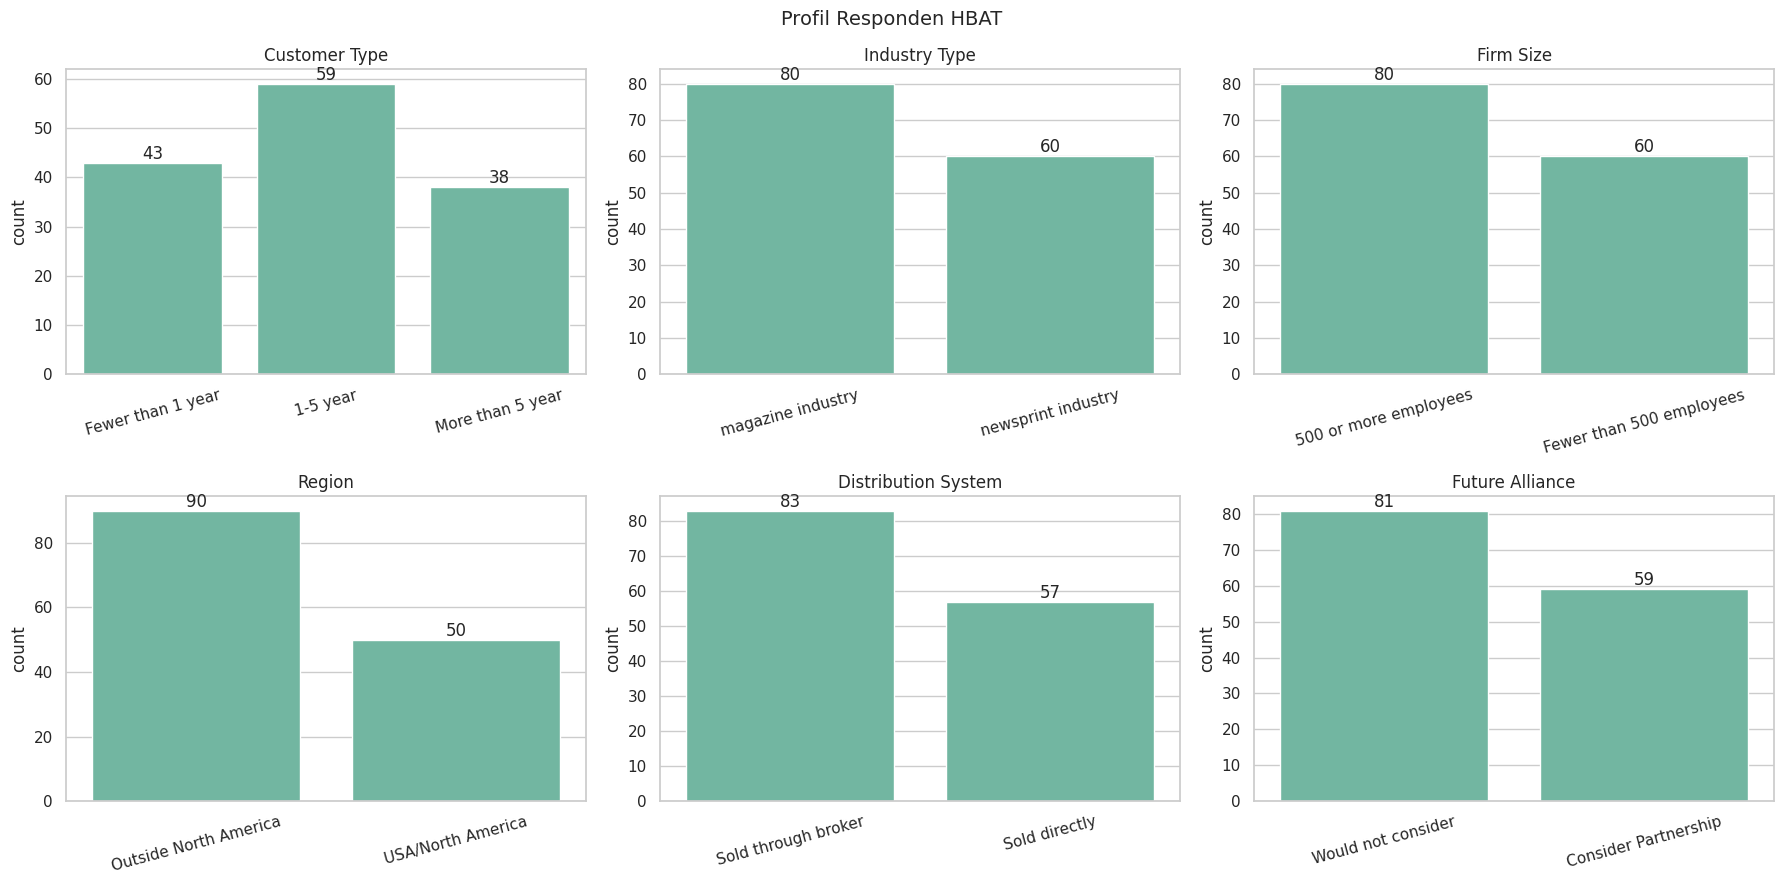

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, kol in enumerate(kolom_kategori):
    sns.countplot(data=df, x=kol, ax=axes[i])
    axes[i].set_title(kol)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15)
    for wadah in axes[i].containers:               # tambahkan angka di atas batang
        axes[i].bar_label(wadah)

plt.suptitle("Profil Responden HBAT", fontsize=14)
plt.tight_layout()
plt.show()

### 9.3 Membandingkan kepuasan antar kelompok (boxplot)
*Pertanyaan: apakah kelompok tertentu lebih puas?*

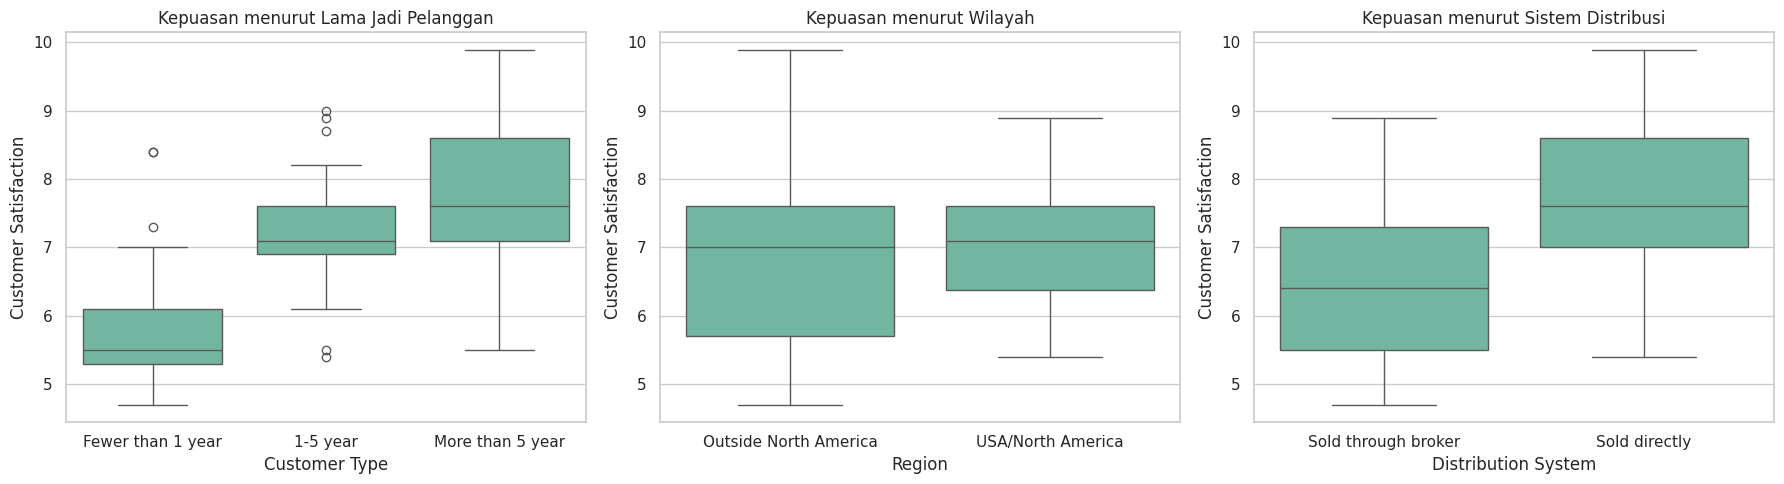

In [ ]:
urutan_customer = ["Fewer than 1 year", "1-5 year", "More than 5 year"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="Customer Type", y="Customer Satisfaction",
            order=urutan_customer, ax=axes[0])
axes[0].set_title("Kepuasan menurut Lama Jadi Pelanggan")

sns.boxplot(data=df, x="Region", y="Customer Satisfaction", ax=axes[1])
axes[1].set_title("Kepuasan menurut Wilayah")

sns.boxplot(data=df, x="Distribution System", y="Customer Satisfaction", ax=axes[2])
axes[2].set_title("Kepuasan menurut Sistem Distribusi")

plt.tight_layout()
plt.show()

### 9.4 Rata-rata skor persepsi per kelompok (bar chart)
*Pertanyaan: aspek mana yang dinilai tinggi/rendah oleh tiap kelompok?*

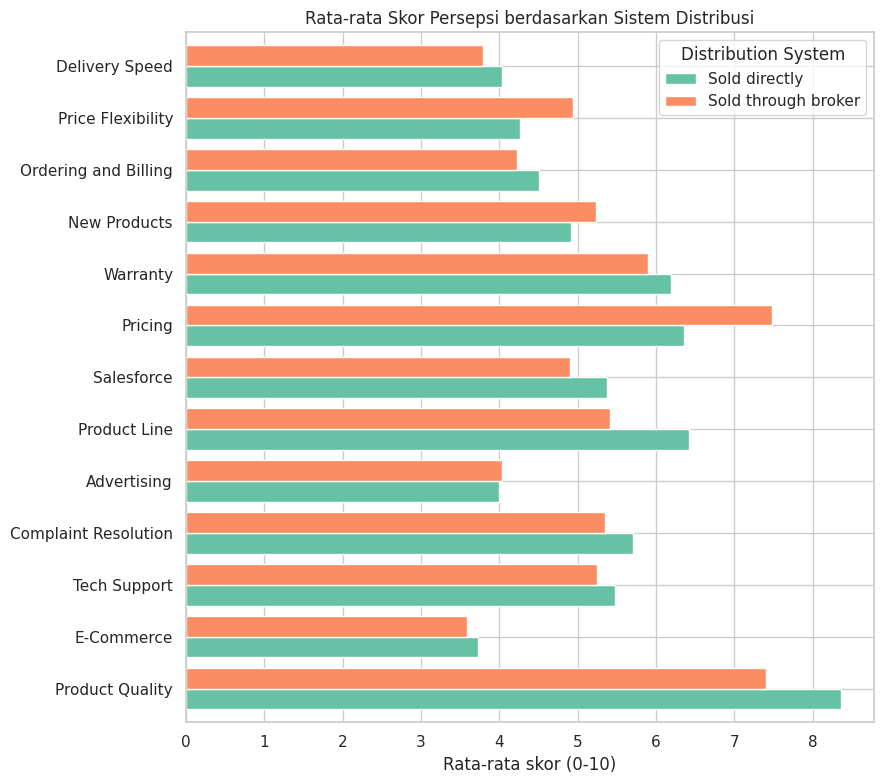

In [ ]:
rata_kelompok = df.groupby("Distribution System")[kolom_persepsi].mean().T

rata_kelompok.plot(kind="barh", figsize=(9, 8), width=0.8)
plt.title("Rata-rata Skor Persepsi berdasarkan Sistem Distribusi")
plt.xlabel("Rata-rata skor (0-10)")
plt.ylabel("")
plt.legend(title="Distribution System")
plt.tight_layout()
plt.show()

### 9.5 Hubungan antar variabel (heatmap korelasi)
*Pertanyaan: variabel mana yang bergerak bersama?* Nilai korelasi berkisar -1 sampai +1. Makin mendekati ±1, makin kuat hubungannya.

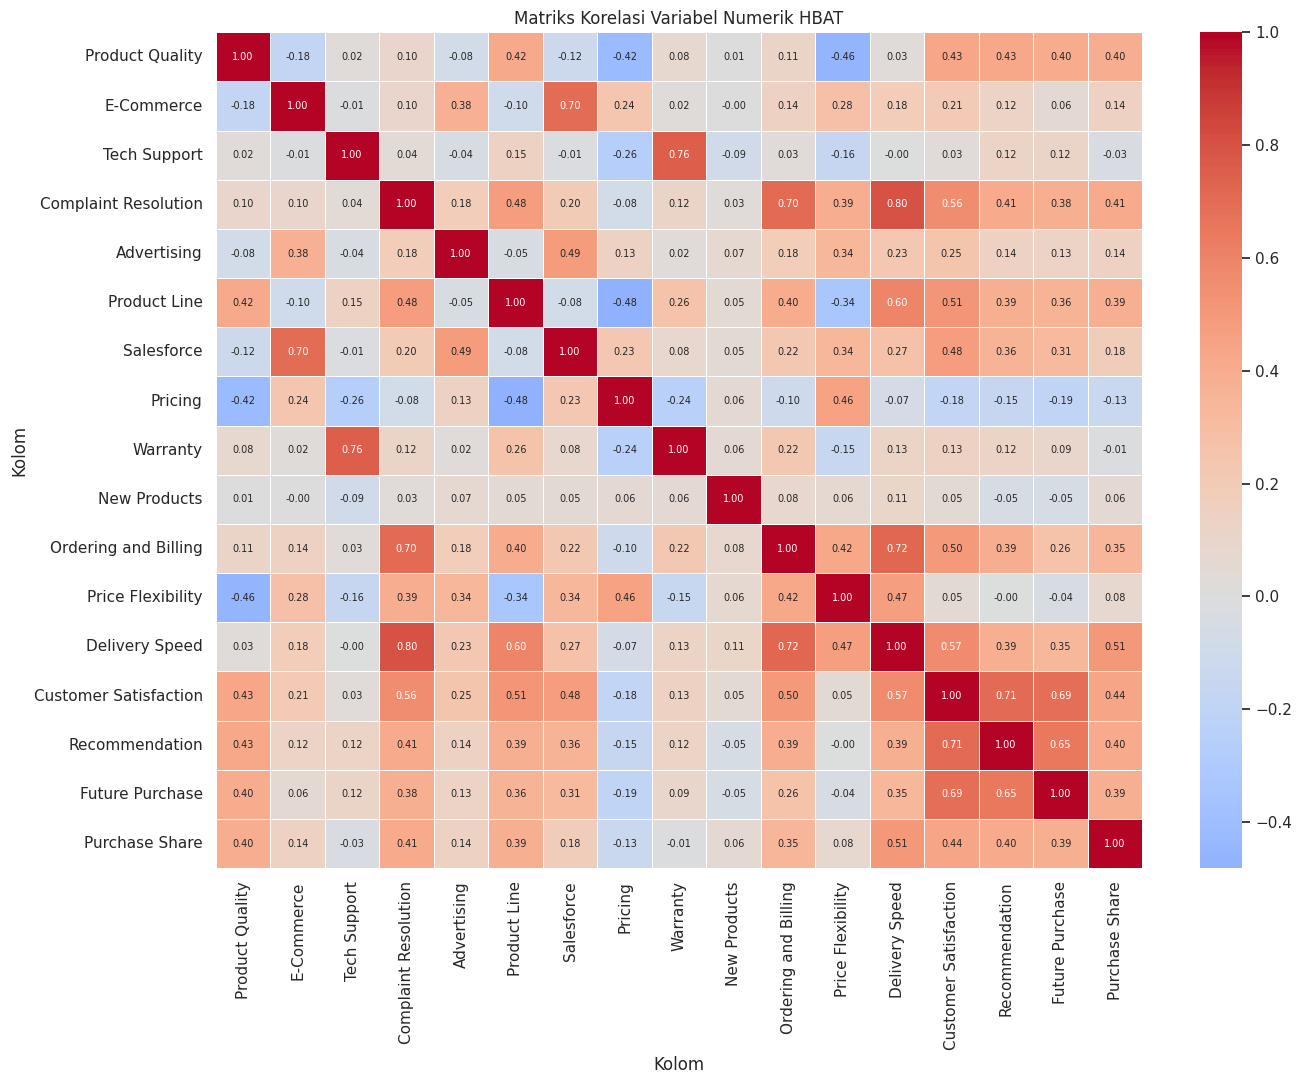

In [ ]:
korelasi = df[kolom_numerik].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(korelasi, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, annot_kws={"size": 7}, linewidths=0.5)
plt.title("Matriks Korelasi Variabel Numerik HBAT")
plt.tight_layout()
plt.show()

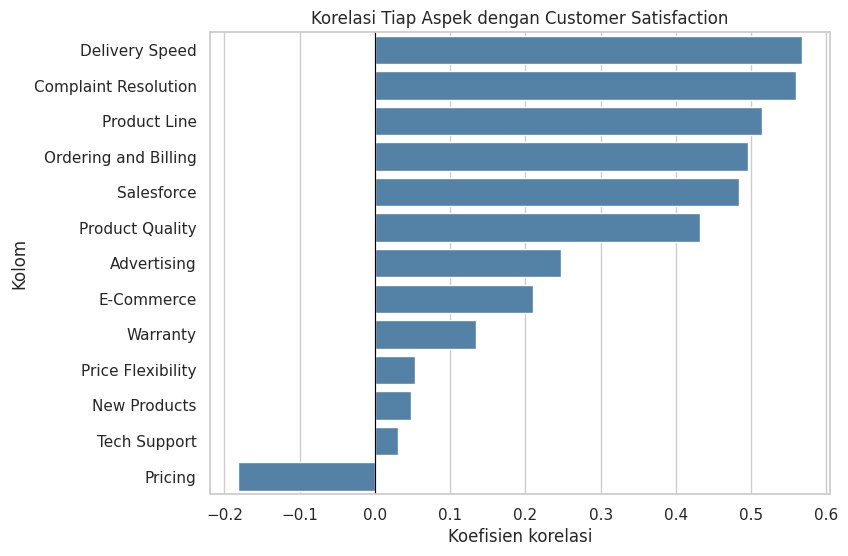

,Customer Satisfaction
Kolom,
Delivery Speed,0.567
Complaint Resolution,0.559
Product Line,0.515
Ordering and Billing,0.496
Salesforce,0.483
Product Quality,0.432
Advertising,0.247
E-Commerce,0.210
Warranty,0.134


In [ ]:
# Variabel persepsi mana yang paling berhubungan dengan Customer Satisfaction?
korelasi_sat = (df[kolom_persepsi + ["Customer Satisfaction"]]
                .corr()["Customer Satisfaction"]
                .drop("Customer Satisfaction")
                .sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.barplot(x=korelasi_sat.values, y=korelasi_sat.index, color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Korelasi Tiap Aspek dengan Customer Satisfaction")
plt.xlabel("Koefisien korelasi")
plt.show()

korelasi_sat.round(3)

### 9.6 Scatter plot dengan garis tren
*Pertanyaan: seperti apa bentuk hubungan 3 aspek terkuat dengan kepuasan?*

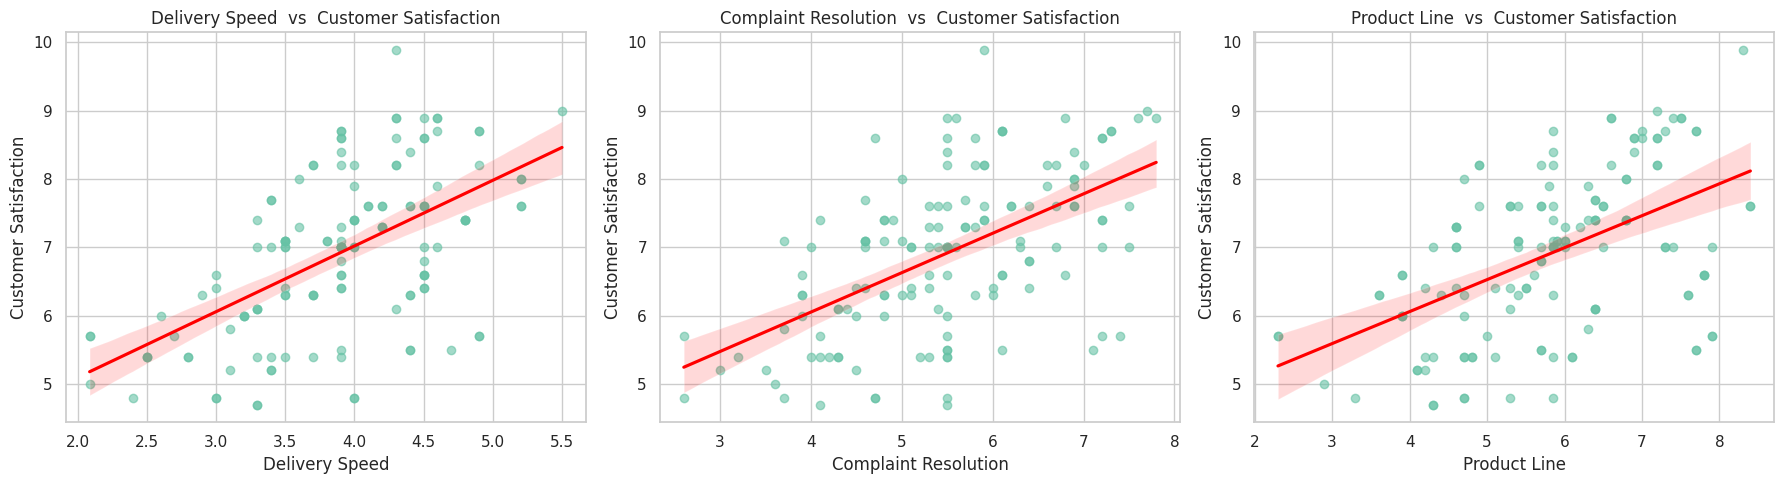

In [ ]:
tiga_teratas = korelasi_sat.index[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, kol in enumerate(tiga_teratas):
    sns.regplot(data=df, x=kol, y="Customer Satisfaction", ax=axes[i],
                scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
    axes[i].set_title(kol + "  vs  Customer Satisfaction")

plt.tight_layout()
plt.show()

### 9.7 Pairplot: banyak hubungan sekaligus
*Pertanyaan: apakah responden yang mau bermitra (Future Alliance) terlihat berbeda?*

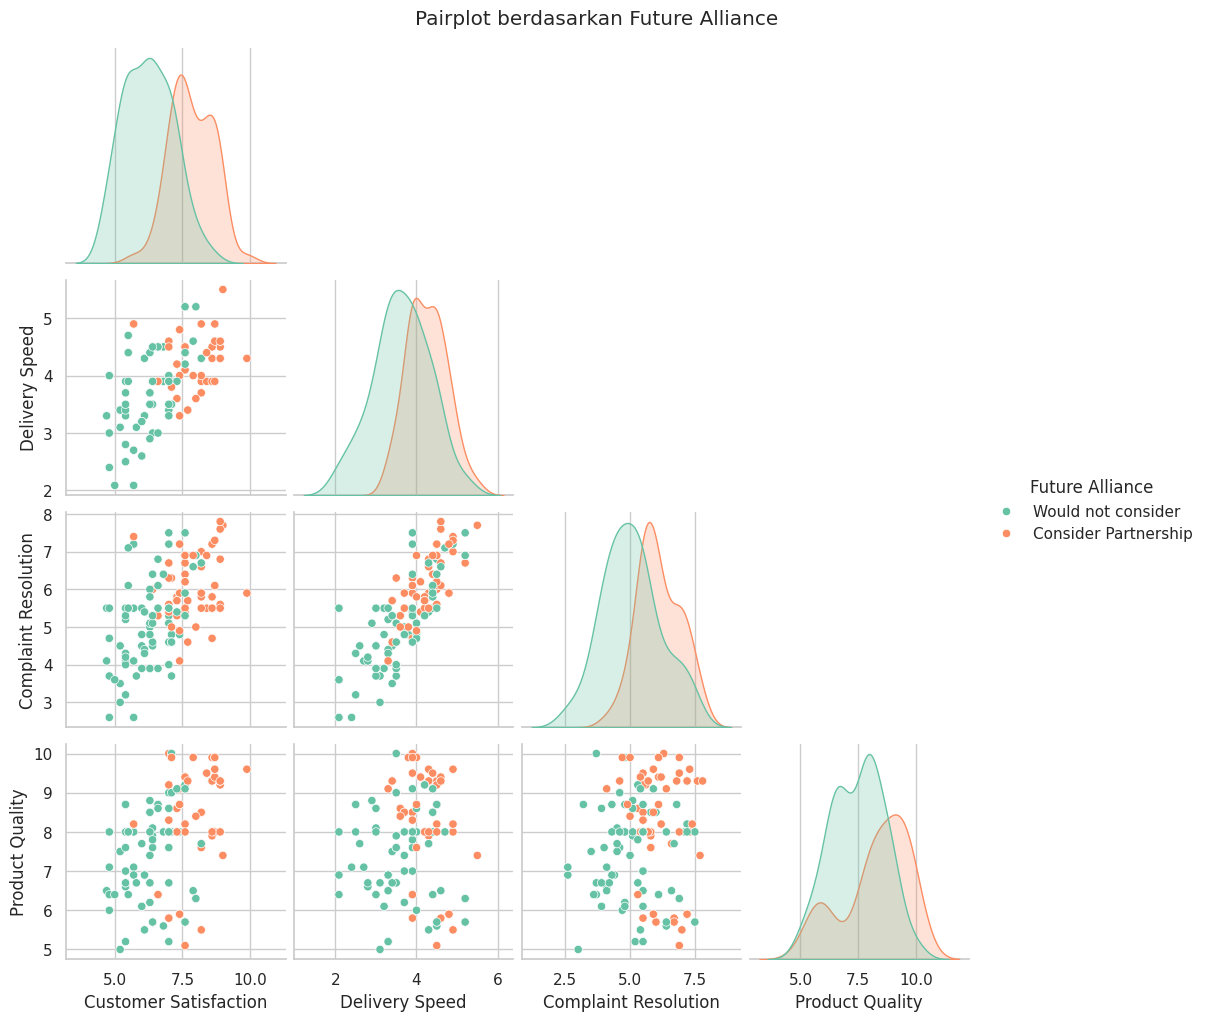

In [ ]:
sns.pairplot(df,
             vars=["Customer Satisfaction", "Delivery Speed", "Complaint Resolution", "Product Quality"],
             hue="Future Alliance", diag_kind="kde", corner=True)
plt.suptitle("Pairplot berdasarkan Future Alliance", y=1.02)
plt.show()

## Langkah 10: Feature Engineering (Membuat Variabel Baru)
13 variabel persepsi cukup banyak. Kita bisa **menggabungkan variabel yang sejenis** menjadi satu skor rata-rata supaya lebih ringkas dan mudah ditafsirkan.

> Pengelompokan di bawah adalah **contoh untuk belajar** (berdasarkan kemiripan makna), bukan hasil analisis faktor.

In [ ]:
df["Skor Layanan"]   = df[["Complaint Resolution", "Delivery Speed", "Ordering and Billing"]].mean(axis=1)
df["Skor Pemasaran"] = df[["E-Commerce", "Advertising", "Salesforce"]].mean(axis=1)
df["Skor Teknis"]    = df[["Tech Support", "Warranty"]].mean(axis=1)
df["Skor Harga"]     = df[["Pricing", "Price Flexibility"]].mean(axis=1)

kolom_skor_baru = ["Skor Layanan", "Skor Pemasaran", "Skor Teknis", "Skor Harga"]
df[kolom_skor_baru].describe().round(2)

Kolom,Skor Layanan,Skor Pemasaran,Skor Teknis,Skor Harga
count,140.00,140.00,140.00,140.00
mean,4.57,4.25,5.68,5.85
std,0.81,0.73,1.05,1.14
min,2.41,2.73,3.08,3.55
25%,4.06,3.79,4.90,4.89
50%,4.63,4.22,5.70,6.01
75%,5.20,4.67,6.24,6.61
max,6.30,6.05,8.10,8.05


### Mengubah angka kontinu menjadi kategori (*binning*)

Kategori Kepuasan
Sedang    79
Rendah    35
Tinggi    26
Name: count, dtype: int64


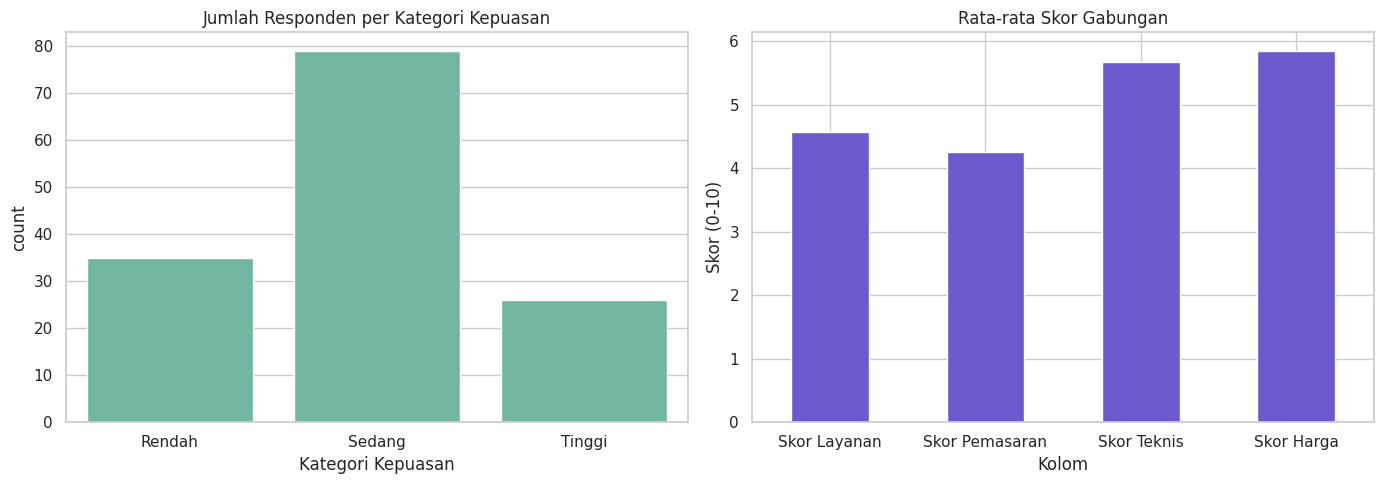

In [ ]:
# Customer Satisfaction -> Rendah / Sedang / Tinggi
df["Kategori Kepuasan"] = pd.cut(df["Customer Satisfaction"],
                                 bins=[0, 6, 8, 10],
                                 labels=["Rendah", "Sedang", "Tinggi"])

print(df["Kategori Kepuasan"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Kategori Kepuasan", ax=axes[0])
axes[0].set_title("Jumlah Responden per Kategori Kepuasan")

df[kolom_skor_baru].mean().plot(kind="bar", ax=axes[1], color="slateblue")
axes[1].set_title("Rata-rata Skor Gabungan")
axes[1].set_ylabel("Skor (0-10)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Langkah 11: Encoding (Mengubah Teks menjadi Angka)
Model hanya mengerti angka. Ada dua cara utama:

| Jenis kategori | Contoh | Teknik |
|---|---|---|
| **Ordinal** (ada urutan) | Customer Type: <1 tahun < 1-5 tahun < >5 tahun | Mapping manual 0, 1, 2 |
| **Biner** (2 pilihan, variabel target) | Future Alliance | Mapping 0 / 1 |
| **Nominal** (tanpa urutan) | Industry Type, Firm Size, Region, Distribution System | **One-Hot Encoding** (`get_dummies`) |

In [ ]:
df_enc = df.copy()

# 1) Ordinal encoding
peta_customer = {"Fewer than 1 year": 0, "1-5 year": 1, "More than 5 year": 2}
df_enc["Customer Type"] = df_enc["Customer Type"].map(peta_customer)

# 2) Binary encoding
peta_alliance = {"Would not consider": 0, "Consider Partnership": 1}
df_enc["Future Alliance"] = df_enc["Future Alliance"].map(peta_alliance)

# 3) One-hot encoding untuk kategori nominal
kolom_nominal = ["Industry Type", "Firm Size", "Region", "Distribution System"]
df_enc = pd.get_dummies(df_enc, columns=kolom_nominal, drop_first=True, dtype=int)

# Pengecekan: pastikan tidak ada label yang gagal dipetakan
print("Missing setelah encoding:", df_enc[["Customer Type", "Future Alliance"]].isnull().sum().sum())
print()
df_enc.head()

Missing setelah encoding: 0



,Respondent ID,Customer Type,Product Quality,E-Commerce,Tech Support,Complaint Resolution,Advertising,Product Line,Salesforce,Pricing,Warranty,New Products,Ordering and Billing,Price Flexibility,Delivery Speed,Customer Satisfaction,Recommendation,Future Purchase,Purchase Share,Future Alliance,Skor Layanan,Skor Pemasaran,Skor Teknis,Skor Harga,Kategori Kepuasan,Industry Type_newsprint industry,Firm Size_Fewer than 500 employees,Region_USA/North America,Distribution System_Sold through broker
0,1,0,8.1,2.5,7.2000,4.5,2.3,5.1,3.8,6.6,6.8,6.1,3.00,3.5,3.0,6.4,5.8,6.2,0.51,0,3.500000,2.866667,7.00000,5.05,Sedang,0,0,0,1
1,2,0,7.6,3.6,7.6000,4.6,4.7,4.6,5.0,7.4,8.1,6.6,4.50,5.8,3.9,6.4,6.9,7.5,0.49,0,4.333333,4.433333,7.85000,6.60,Sedang,0,1,0,0
2,4,1,7.4,4.8,4.8000,7.7,4.5,7.2,6.9,9.6,6.4,7.4,5.70,6.5,5.5,9.0,7.9,8.8,0.74,1,6.300000,5.400000,5.60000,8.05,Tinggi,0,0,0,0
3,5,2,9.1,4.5,3.6000,6.4,5.3,5.3,7.1,8.4,5.8,6.7,4.50,6.1,4.4,7.6,8.5,8.8,0.67,1,5.100000,5.633333,4.70000,7.25,Sedang,0,0,0,1
4,6,0,5.0,3.6,1.8625,3.0,3.5,4.2,4.9,8.2,4.3,7.6,2.55,4.8,3.1,5.2,5.5,6.0,0.48,0,2.883333,4.000000,3.08125,6.50,Rendah,0,1,0,1


> 💡 `drop_first=True` membuang satu kategori agar tidak terjadi duplikasi informasi (*dummy variable trap*). Contoh: jika `Region_USA/North America = 0`, otomatis berarti "Outside North America".

## Langkah 12: Membagi Data dan Scaling
### 12.1 Pisahkan fitur (X) dan target (y)
Sebagai contoh, targetnya adalah **Customer Satisfaction**, dan fiturnya 13 variabel persepsi + profil pelanggan.

### 12.2 Bagi data latih dan data uji
Data dibagi **80% latih** (untuk belajar) dan **20% uji** (untuk menguji). `random_state=42` supaya pembagiannya sama setiap dijalankan.

In [ ]:
kolom_dummy = [c for c in df_enc.columns if c.startswith(tuple(k + "_" for k in kolom_nominal))]
fitur = kolom_persepsi + ["Customer Type"] + kolom_dummy

X = df_enc[fitur]
y = df_enc["Customer Satisfaction"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Fitur yang dipakai:", len(fitur), "kolom")
print("Data latih:", X_train.shape, "| Data uji:", X_test.shape)

Fitur yang dipakai: 18 kolom
Data latih: (112, 18) | Data uji: (28, 18)


### 12.3 Scaling (menyamakan skala)
Variabel dengan skala berbeda bisa mendominasi model tertentu. Dua teknik populer:

| Teknik | Hasil | Rumus |
|---|---|---|
| **StandardScaler** (standarisasi) | rata-rata 0, simpangan baku 1 | (x - mean) / std |
| **MinMaxScaler** (normalisasi) | rentang 0 sampai 1 | (x - min) / (max - min) |

> ⚠️ **Aturan emas:** `fit` scaler **hanya pada data latih**, lalu `transform` ke data latih dan data uji. Kalau `fit` memakai seluruh data, informasi data uji "bocor" ke proses belajar (*data leakage*).

In [ ]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# Hanya kolom persepsi yang di-scaling (kolom hasil encoding sudah 0/1)
X_train_scaled[kolom_persepsi] = scaler.fit_transform(X_train[kolom_persepsi])   # fit + transform
X_test_scaled[kolom_persepsi]  = scaler.transform(X_test[kolom_persepsi])        # transform saja

print("Rata-rata data latih setelah scaling (hampir 0):")
print(X_train_scaled[kolom_persepsi].mean().round(3).head())
print()
print("Simpangan baku data latih setelah scaling (hampir 1):")
print(X_train_scaled[kolom_persepsi].std().round(3).head())

Rata-rata data latih setelah scaling (hampir 0):
Product Quality        -0.0
E-Commerce             -0.0
Tech Support           -0.0
Complaint Resolution    0.0
Advertising             0.0
dtype: float64

Simpangan baku data latih setelah scaling (hampir 1):
Product Quality         1.004
E-Commerce              1.004
Tech Support            1.004
Complaint Resolution    1.004
Advertising             1.004
dtype: float64


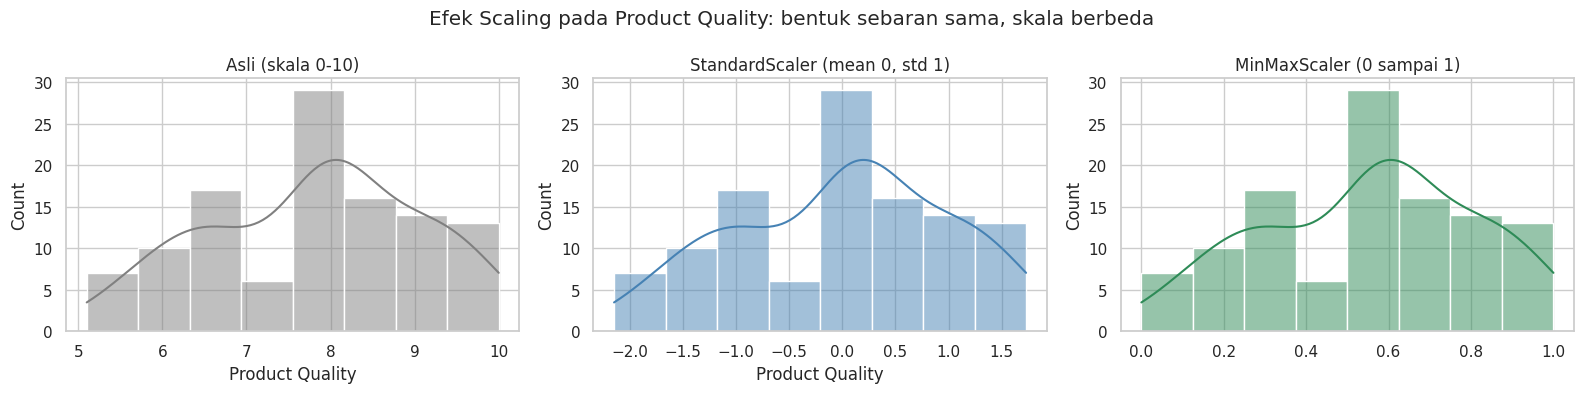

In [ ]:
# Visual: sebelum scaling vs StandardScaler vs MinMaxScaler
kol = "Product Quality"

mm = MinMaxScaler()
minmax_hasil = mm.fit_transform(X_train[[kol]])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(X_train[kol], kde=True, ax=axes[0], color="gray")
axes[0].set_title("Asli (skala 0-10)")

sns.histplot(X_train_scaled[kol], kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("StandardScaler (mean 0, std 1)")

sns.histplot(minmax_hasil.ravel(), kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("MinMaxScaler (0 sampai 1)")

plt.suptitle("Efek Scaling pada " + kol + ": bentuk sebaran sama, skala berbeda")
plt.tight_layout()
plt.show()

## Langkah 13: Menyimpan Data Bersih
Hasil kerja jangan sampai hilang. File di Colab akan terhapus saat sesi berakhir, jadi **unduh** hasilnya.

In [ ]:
# Data bersih (masih berupa teks yang terbaca manusia)
df.to_excel("HBAT_bersih.xlsx", index=False)

# Data siap model (sudah di-encoding)
df_enc.to_csv("HBAT_siap_model.csv", index=False)

# Unduh ke komputer
files.download("HBAT_bersih.xlsx")
files.download("HBAT_siap_model.csv")

print("Selesai! Dimensi data bersih:", df.shape, "| data siap model:", df_enc.shape)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Selesai! Dimensi data bersih: (140, 29) | data siap model: (140, 29)


## 🎯 Rangkuman Alur Preprocessing

```
Data mentah
   ↓ 1. Eksplorasi (shape, info, describe)
   ↓ 2. Rapikan nama kolom & label (typo, spasi)
   ↓ 3. Cek & buang duplikat
   ↓ 4. Missing value: buang baris terlalu kosong → imputasi median/modus
   ↓ 5. Validasi rentang nilai
   ↓ 6. Outlier: deteksi IQR → capping
   ↓ 7. Visualisasi EDA
   ↓ 8. Feature engineering (skor gabungan, binning)
   ↓ 9. Encoding (ordinal, biner, one-hot)
   ↓ 10. Split latih/uji → Scaling (fit hanya di data latih)
Data siap dianalisis / dimodelkan
```

## 📝 Tugas Mandiri
1. Ubah `batas_missing` menjadi `0.20` dan `0.60`. Berapa baris yang terbuang? Apa dampaknya pada hasil korelasi?
2. Ganti imputasi median menjadi **mean**. Bandingkan tabel *Mean/Std sebelum vs sesudah*.
3. Coba imputasi lanjutan dengan `KNNImputer` dari `sklearn.impute`, lalu bandingkan dengan median.
4. Buat boxplot **Skor Layanan** berdasarkan `Firm Size`. Apa kesimpulanmu?
5. Pilih target **Future Alliance** (klasifikasi), bagi data dengan `stratify=y`, lalu latih `LogisticRegression` pada data yang sudah di-scaling.
6. Tulis 5 kalimat: keputusan preprocessing apa yang menurutmu paling berpengaruh pada hasil akhir, dan mengapa?